In [1]:
import pandas as pd
import numpy as np
import sys
import random
import logomaker
import os
import matplotlib.pyplot as plt
import glob

In [2]:
this_path = os.getcwd()
results_path = '/home/gralak/updepla/users/gralak/SmileSeq_paper/meSMiLEseq_separated_analysis/psam_used_in_pub/'
sys.path.append('/data/gralak/meSMiLEseq_github/meSMiLEseq/separate_analysis')
import functions

In [3]:
files = glob.glob('/home/gralak/updepla/users/gralak/SmileSeq_paper/meSMiLEseq_separated_analysis/psam_used_in_pub/*_bindingmode_1.csv')

In [48]:
# Extract name of the TF
#file[0].split('/')[-1][:-4]

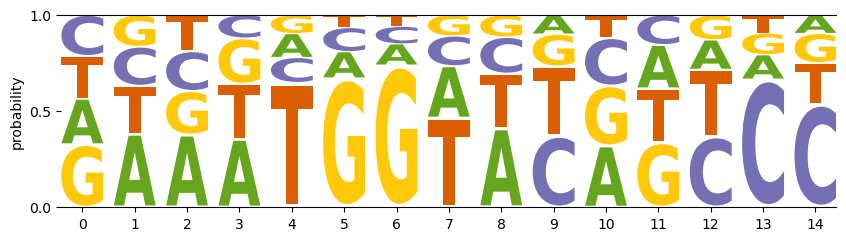

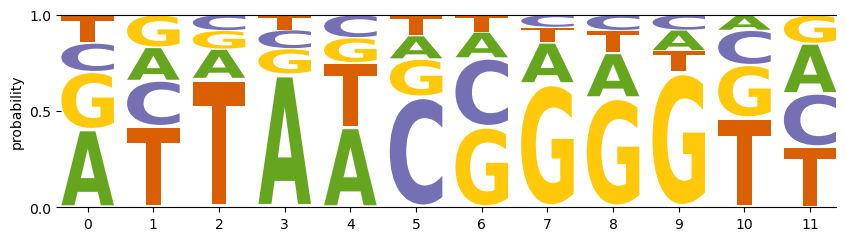

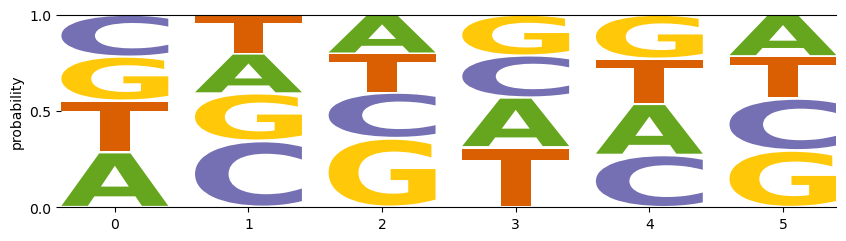

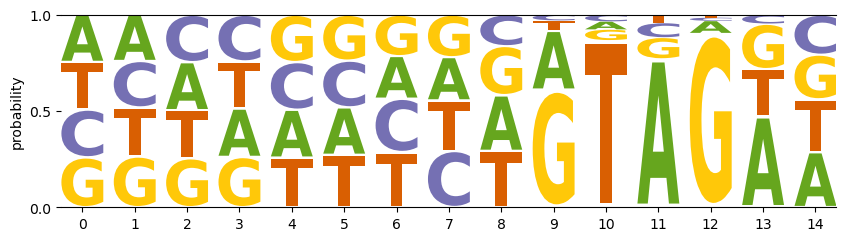

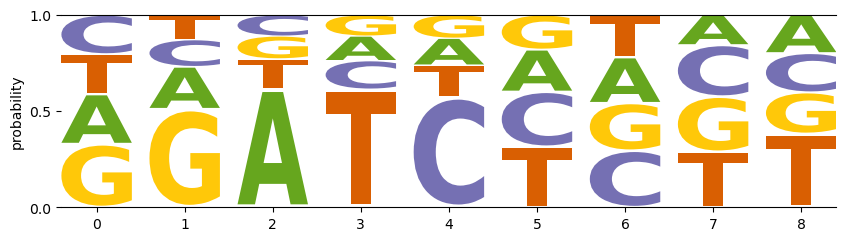

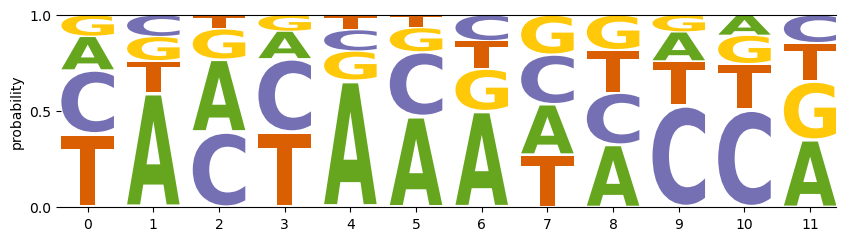

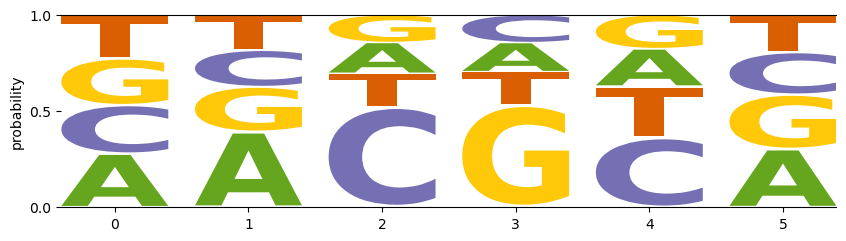

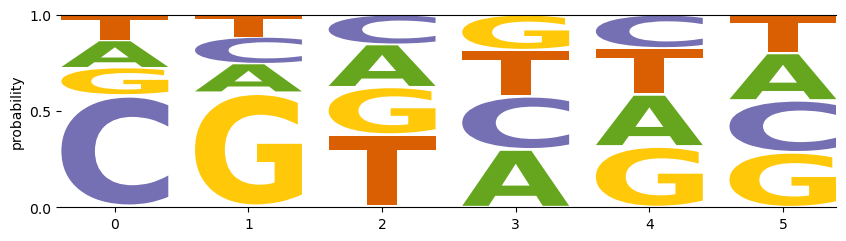

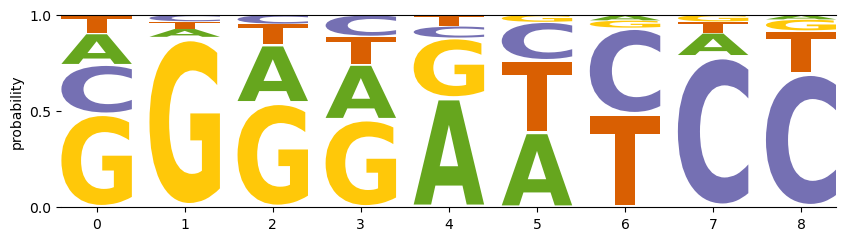

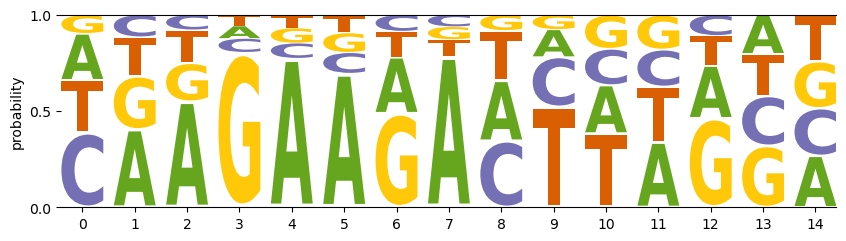

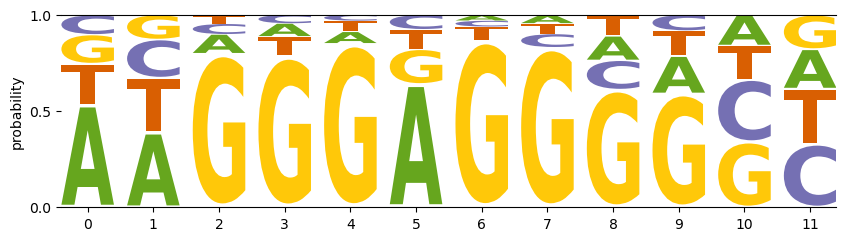

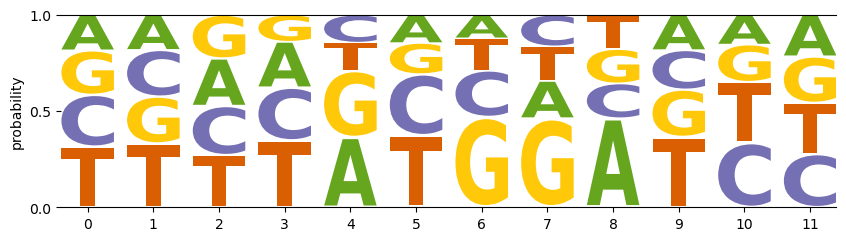

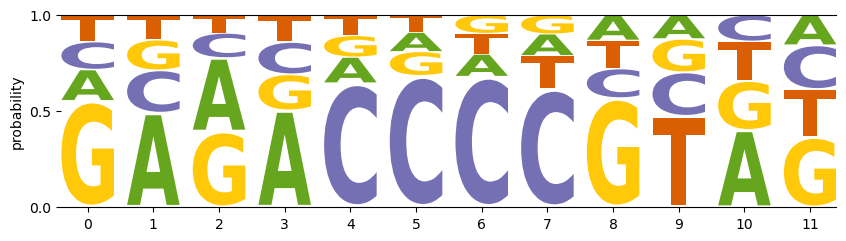

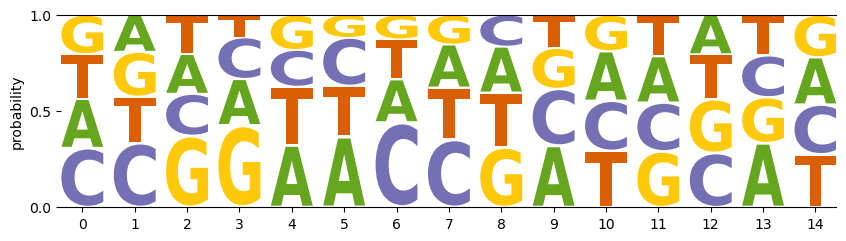

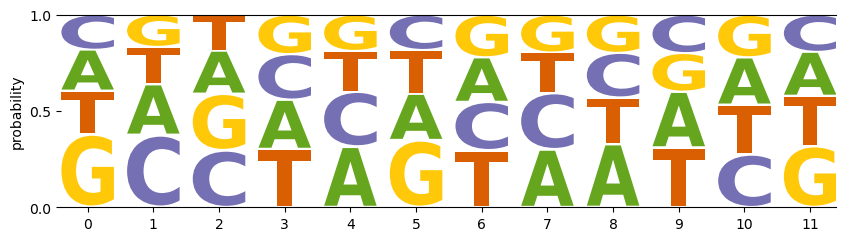

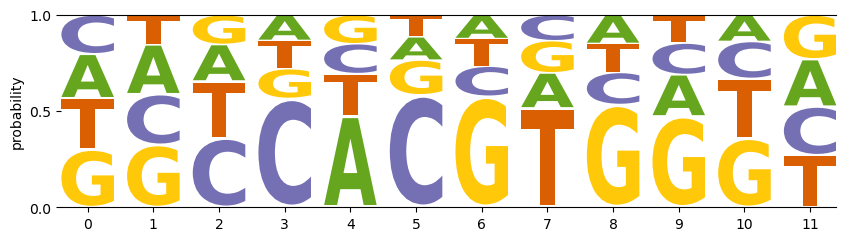

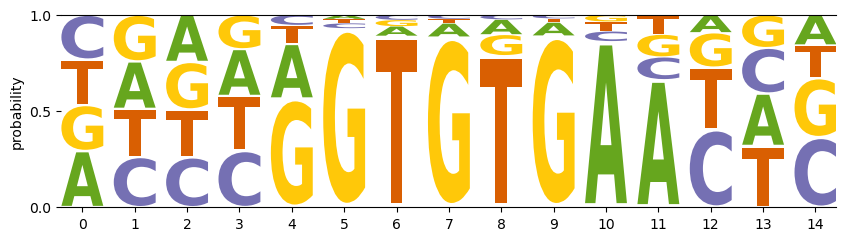

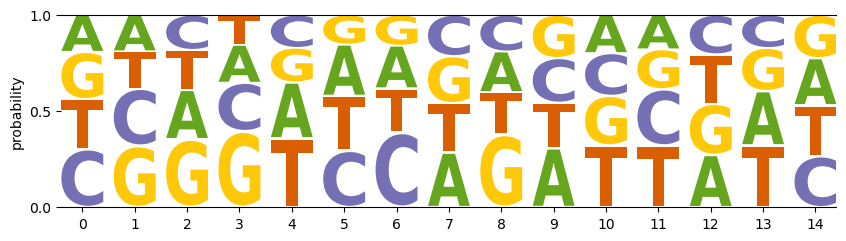

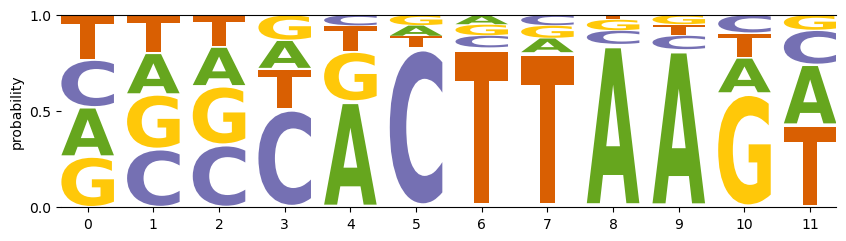

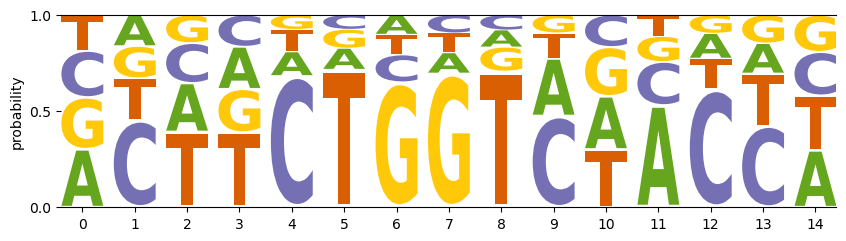

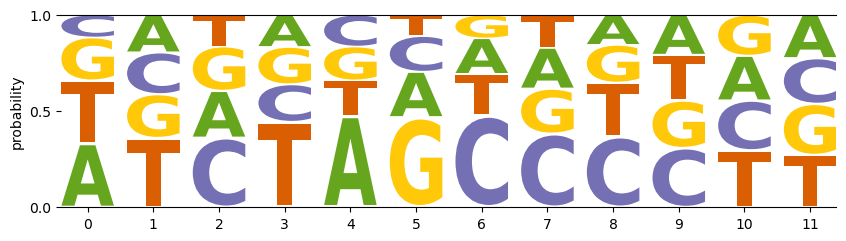

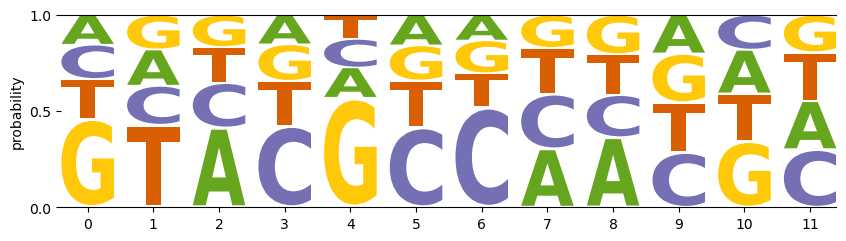

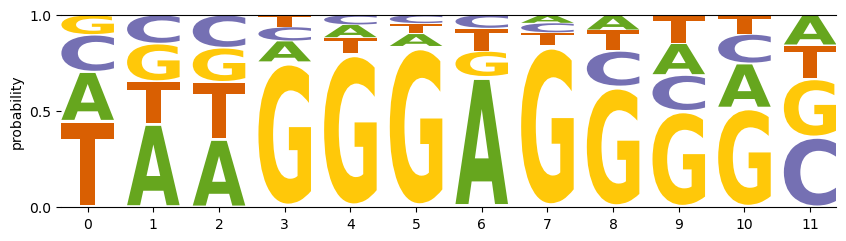

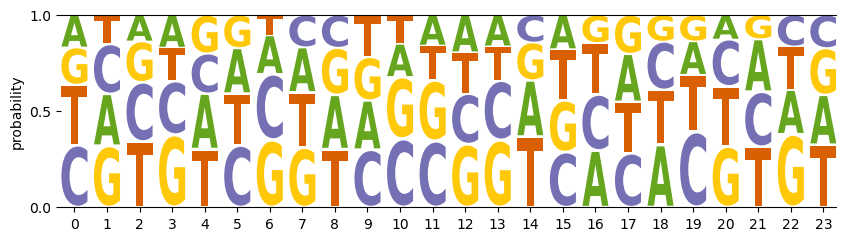

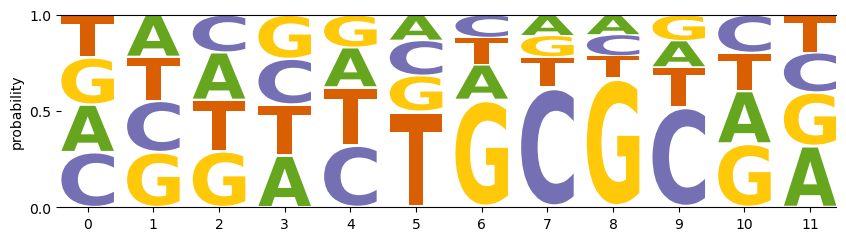

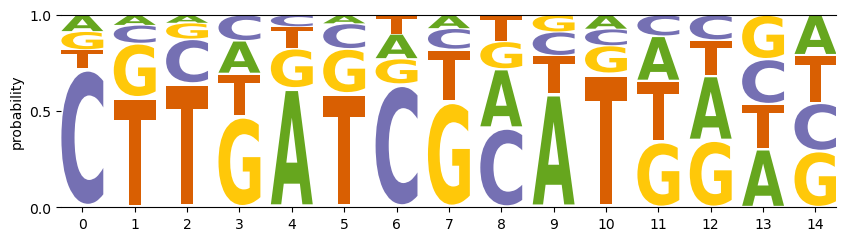

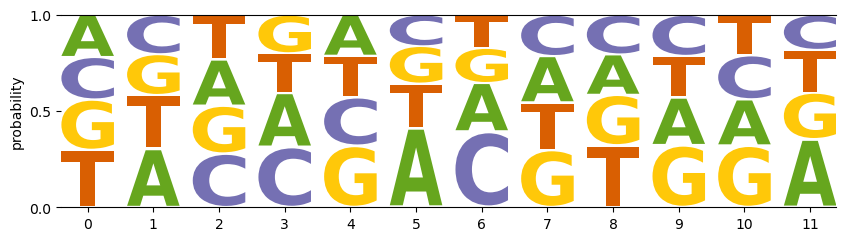

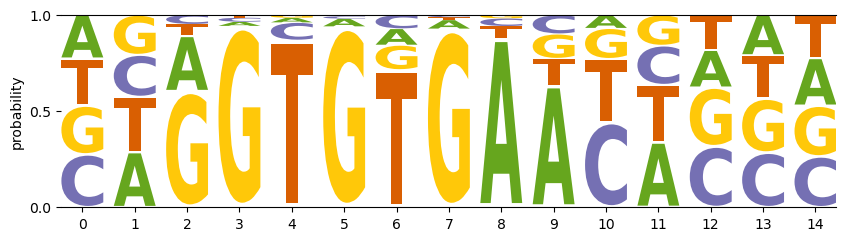

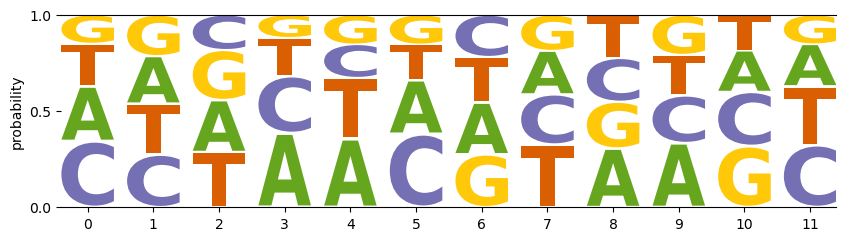

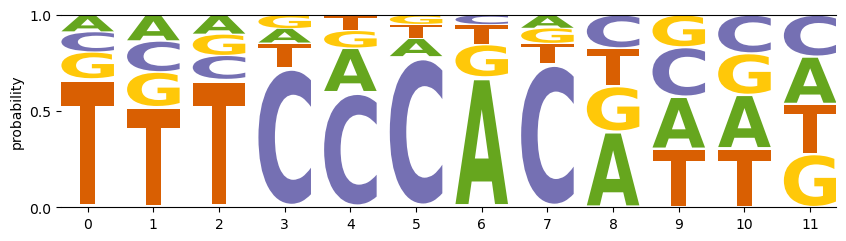

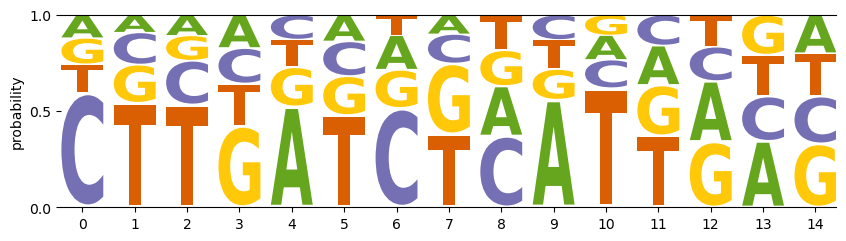

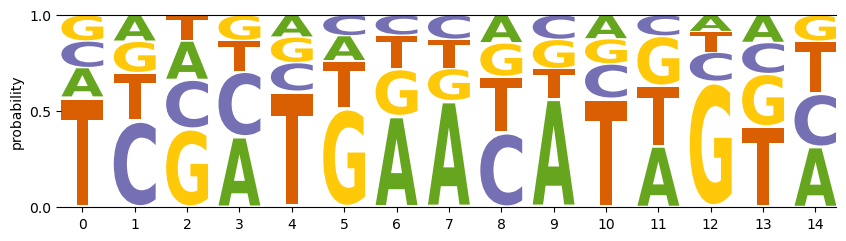

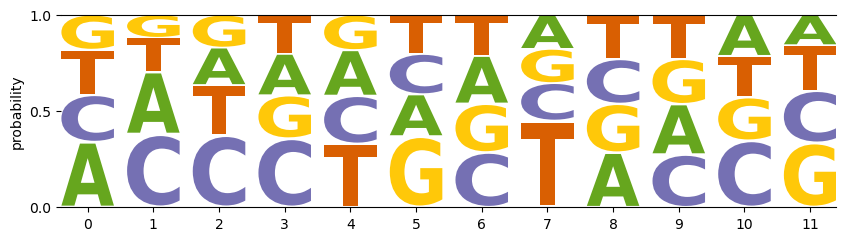

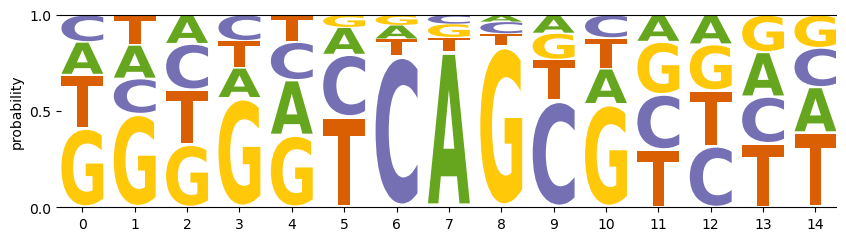

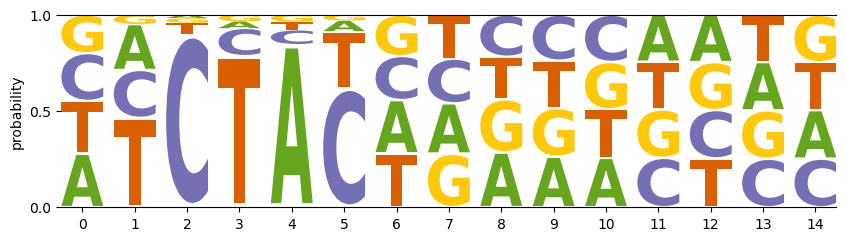

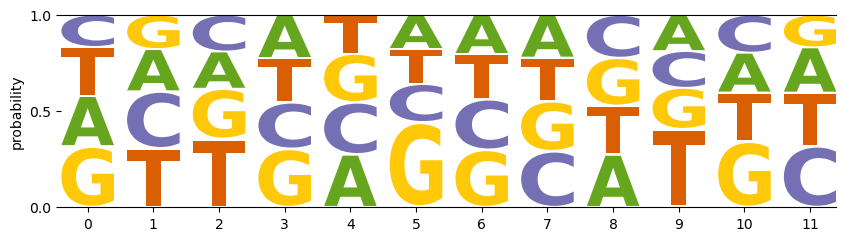

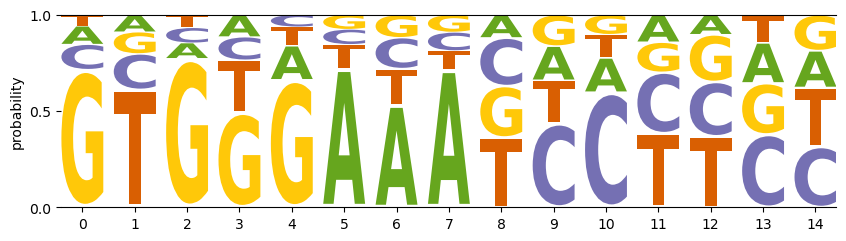

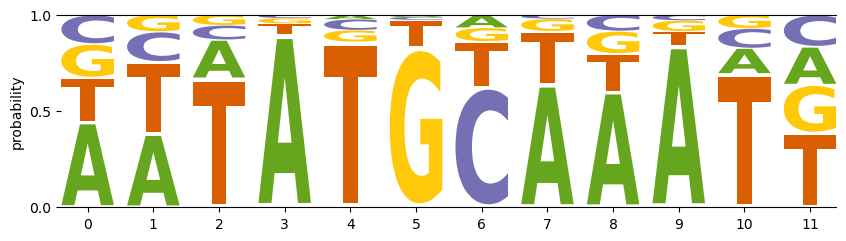

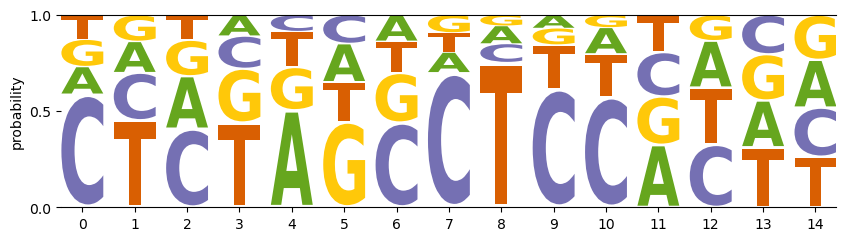

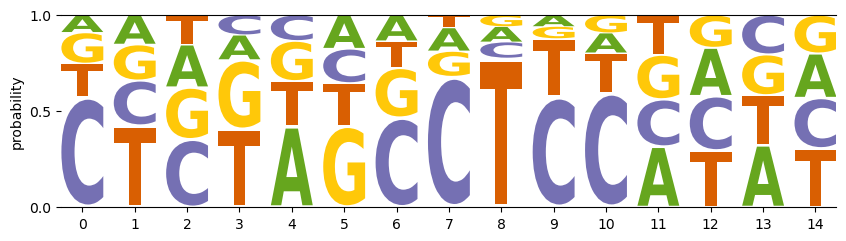

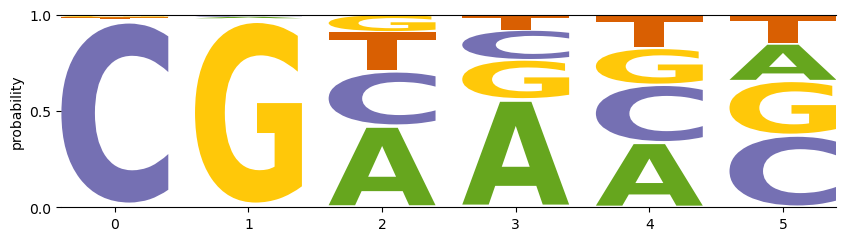

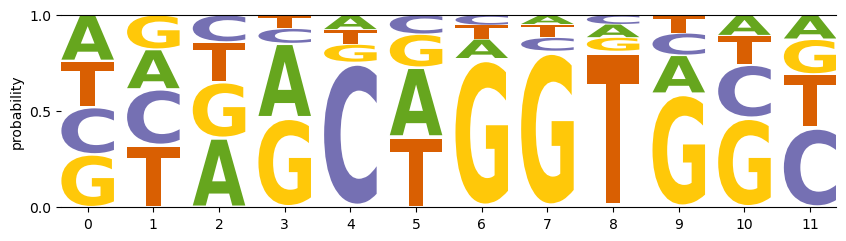

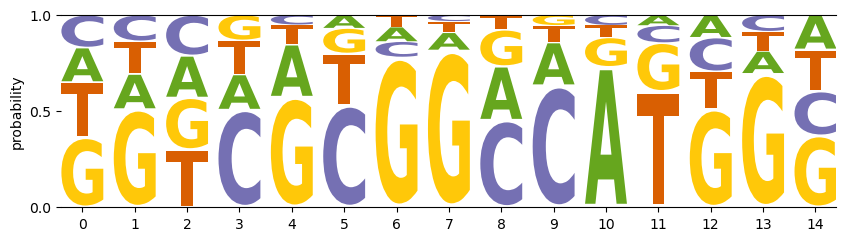

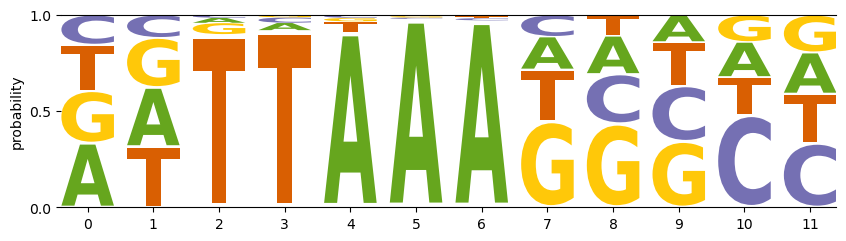

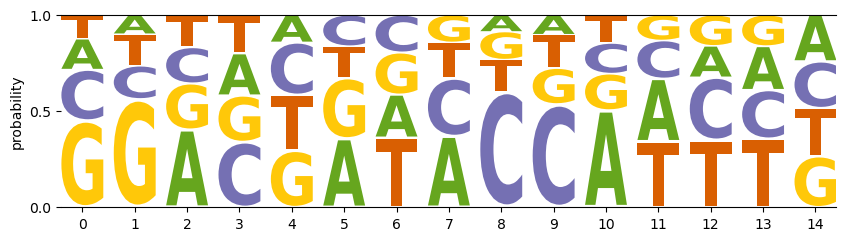

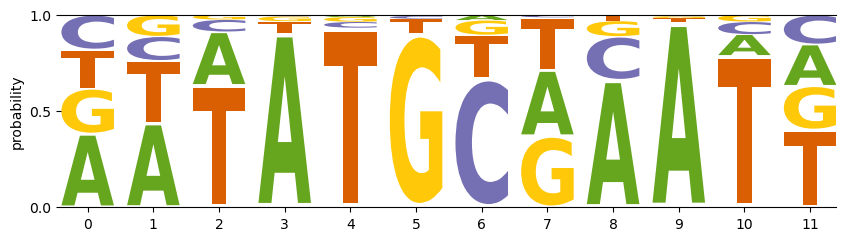

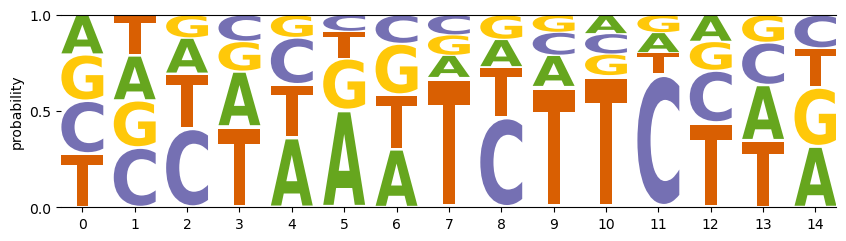

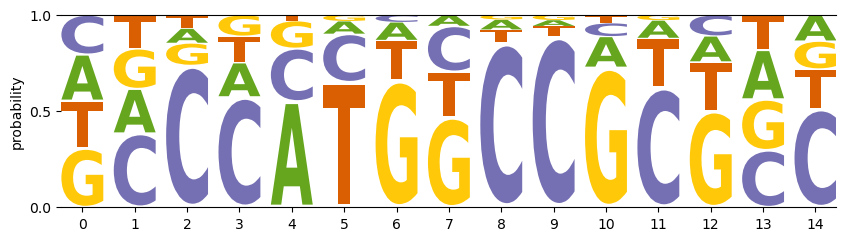

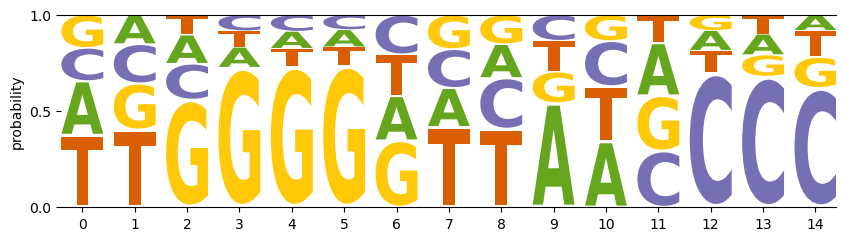

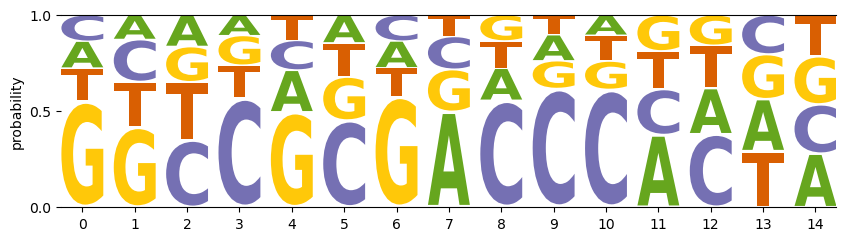

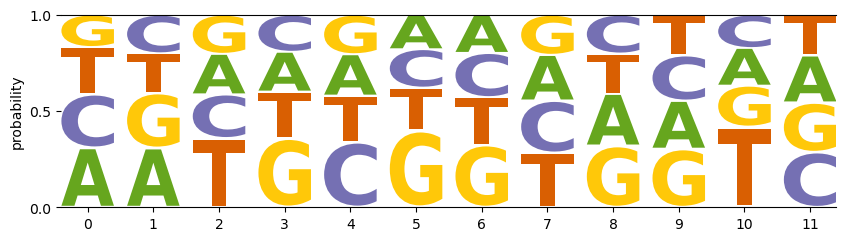

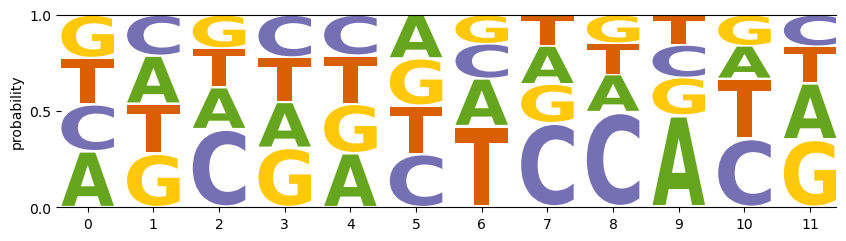

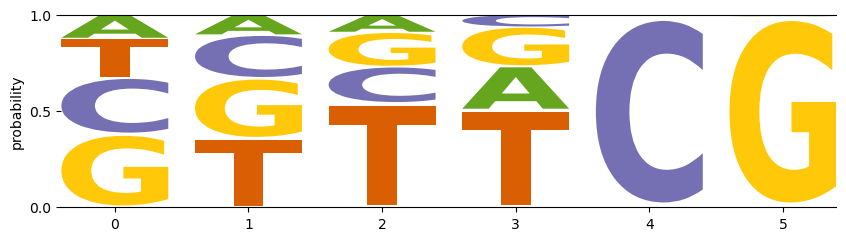

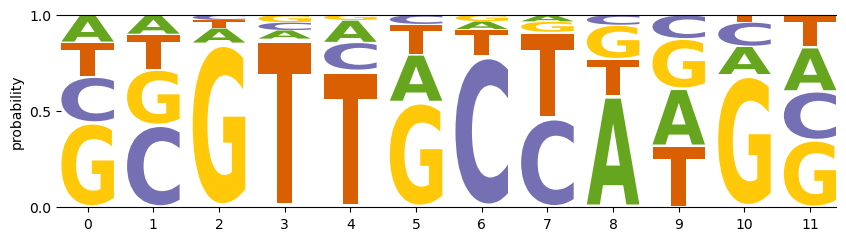

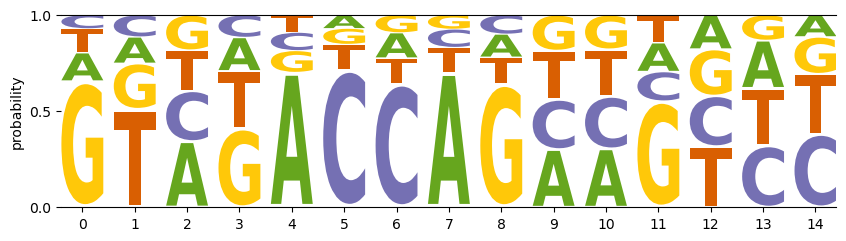

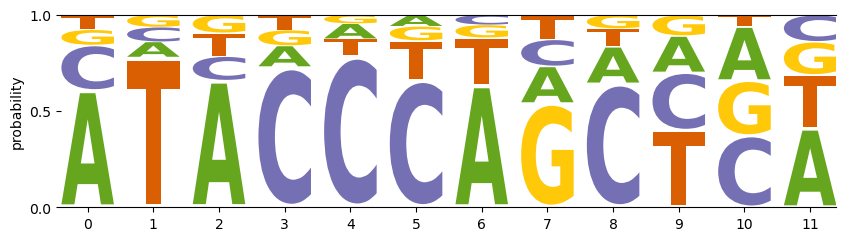

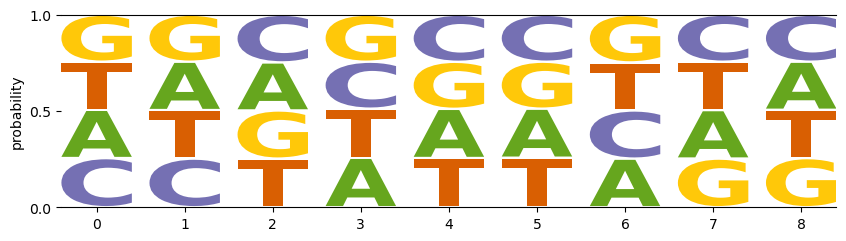

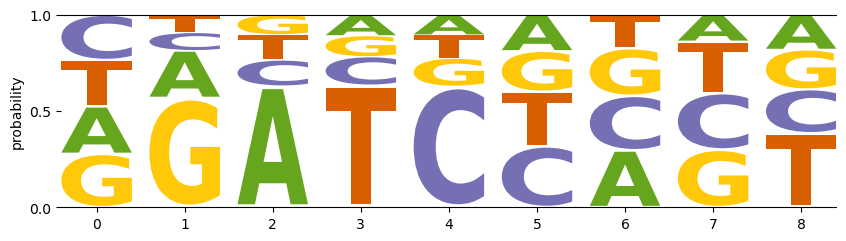

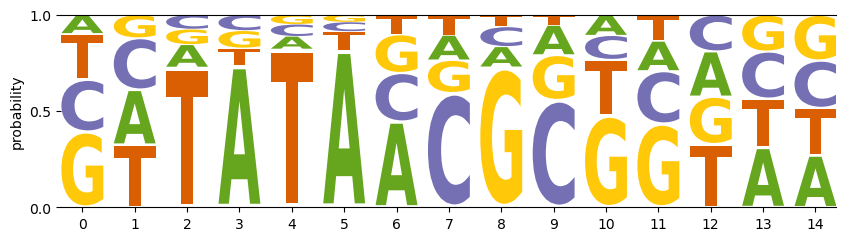

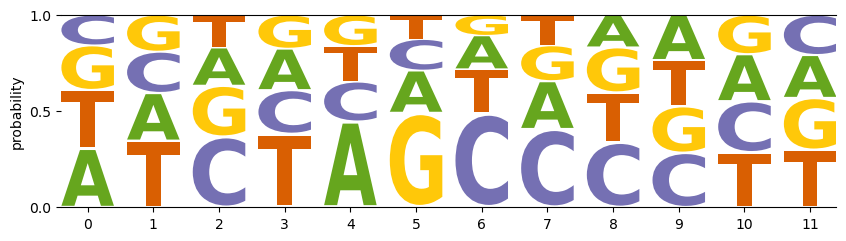

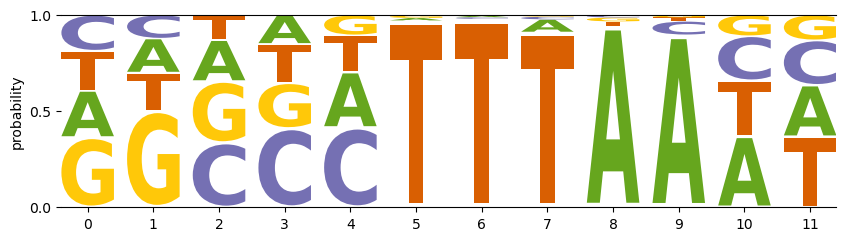

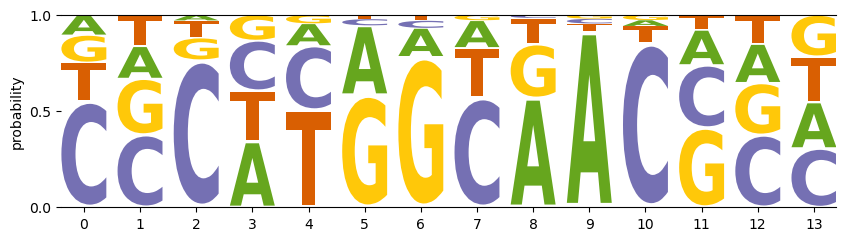

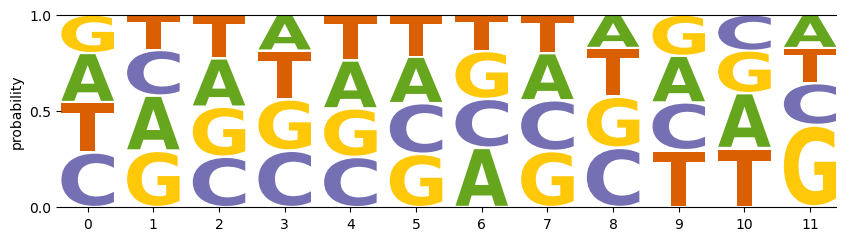

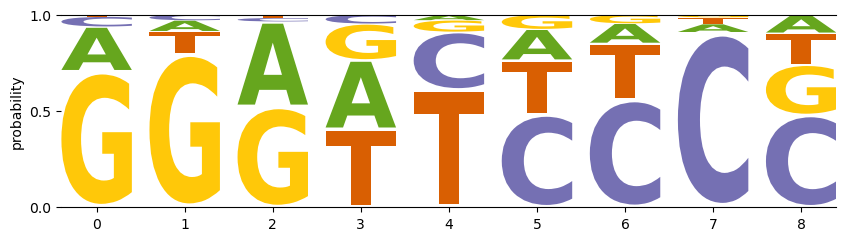

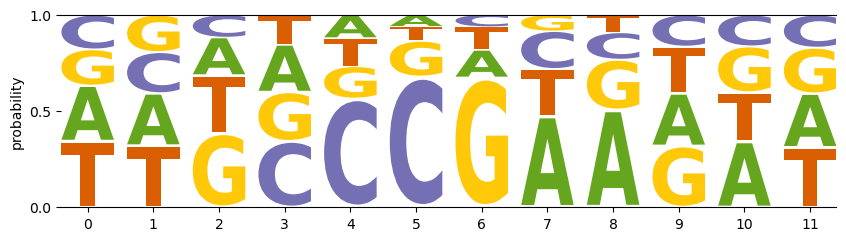

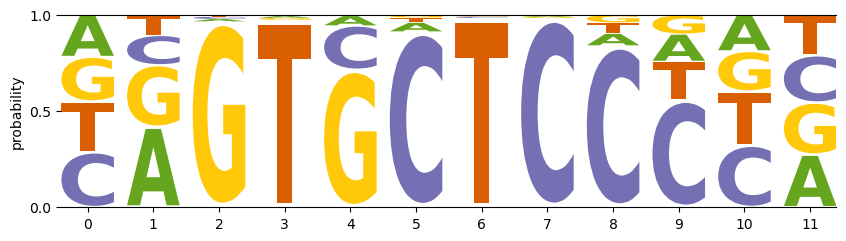

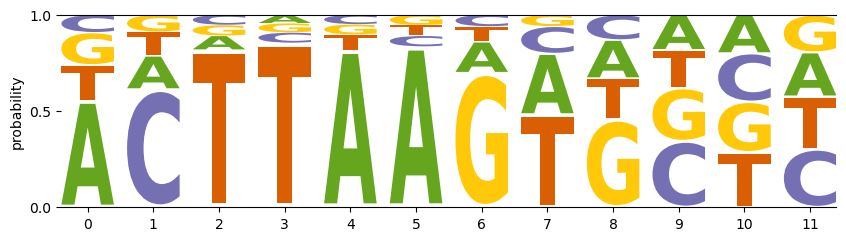

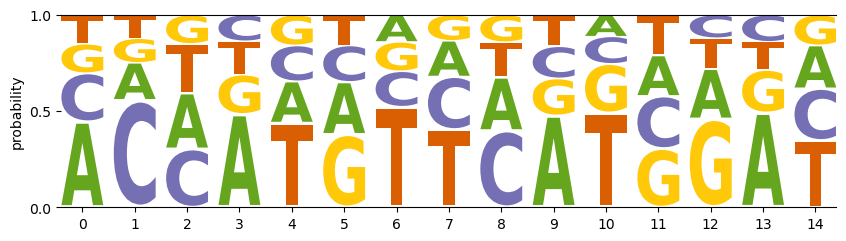

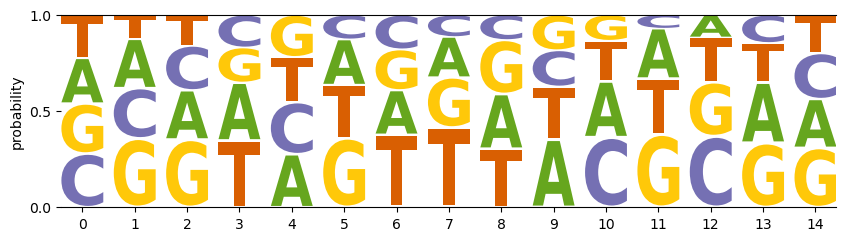

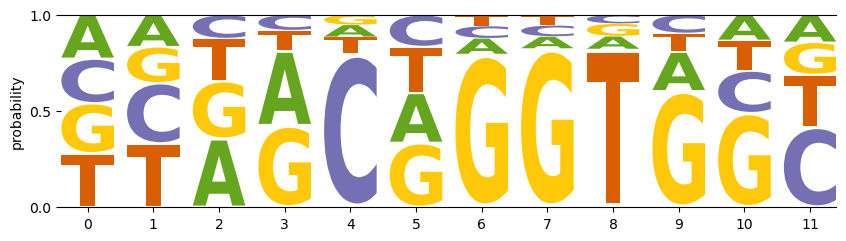

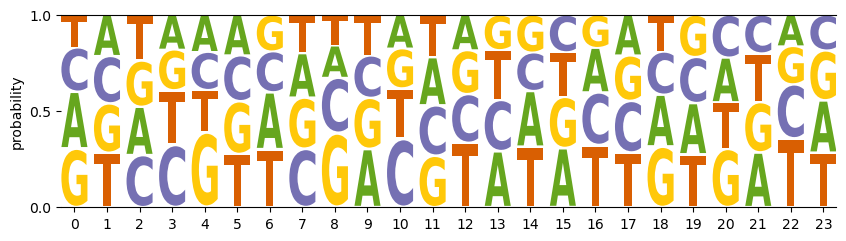

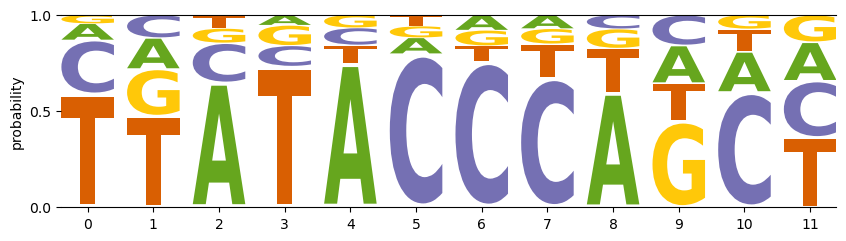

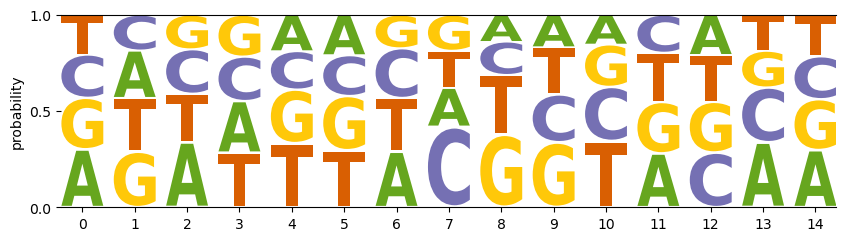

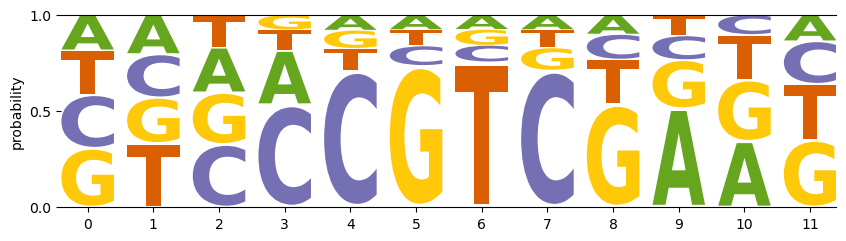

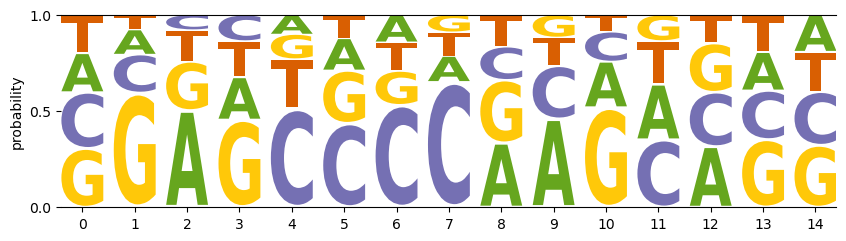

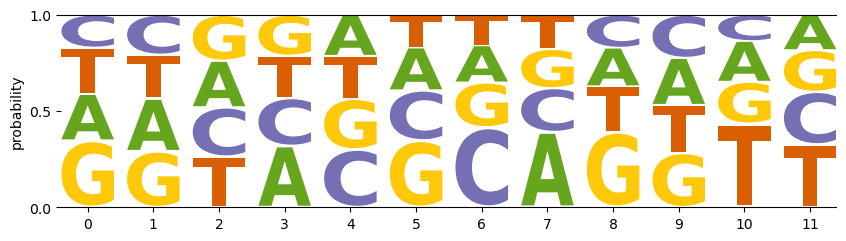

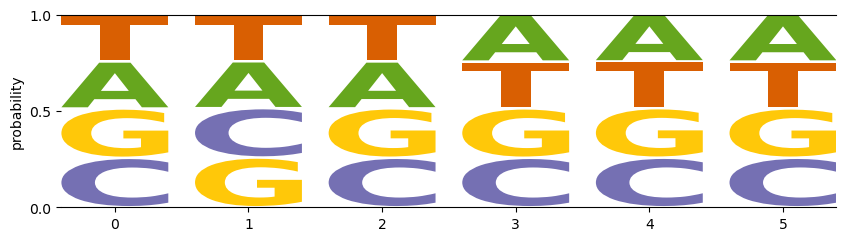

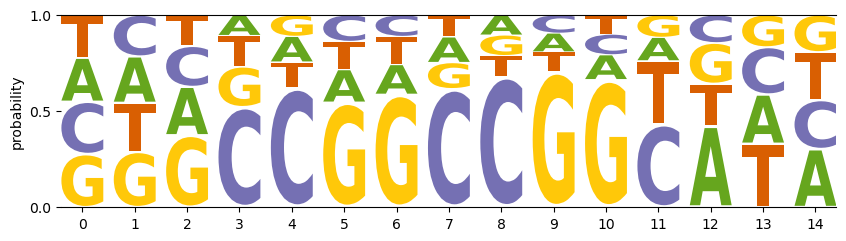

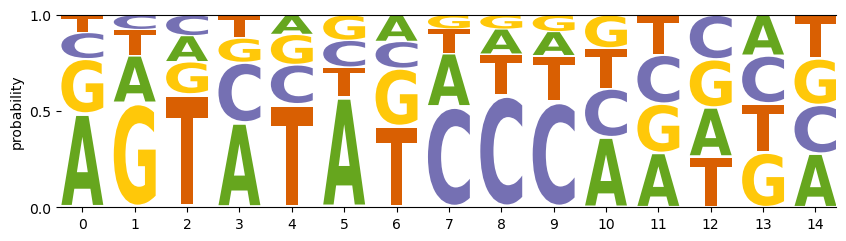

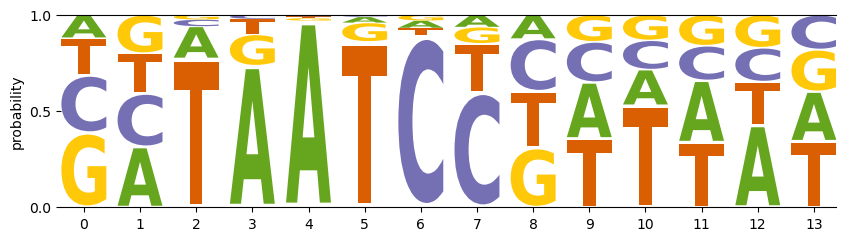

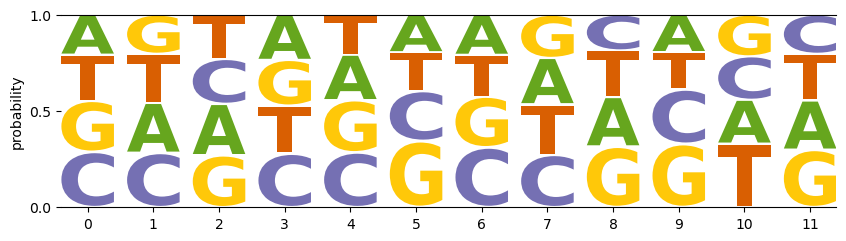

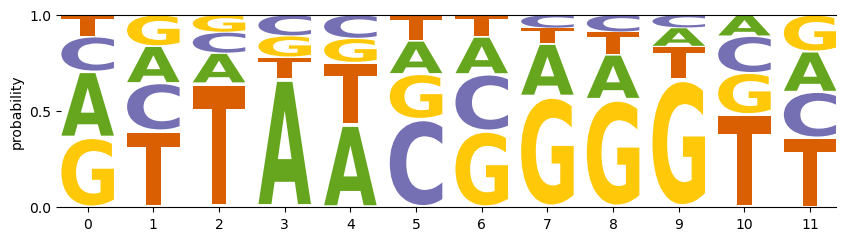

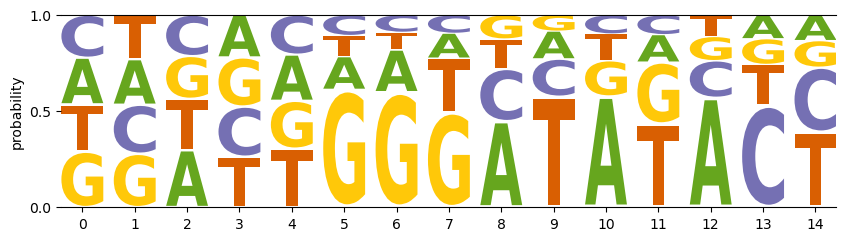

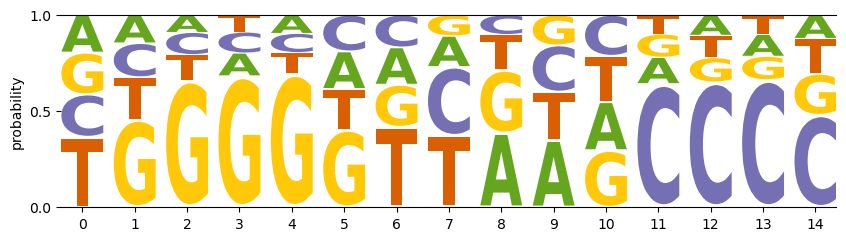

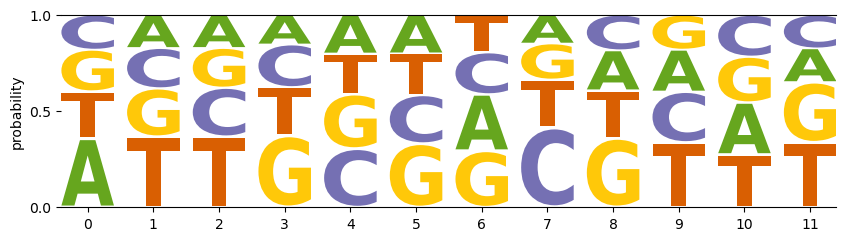

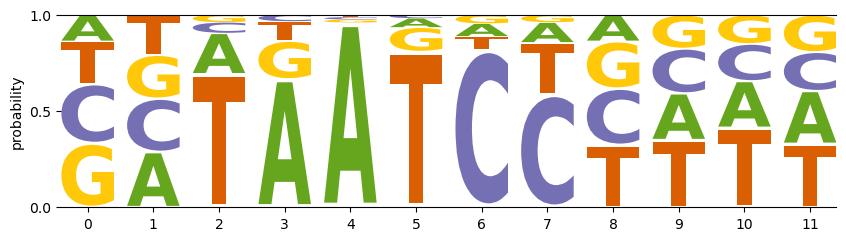

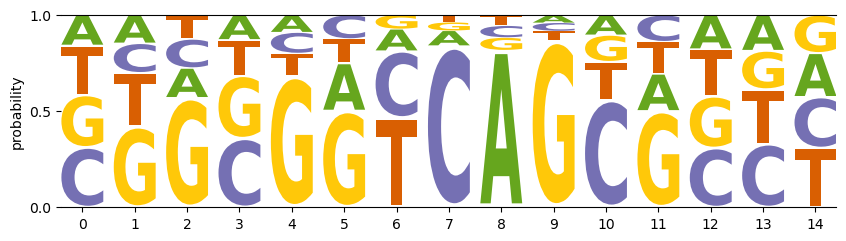

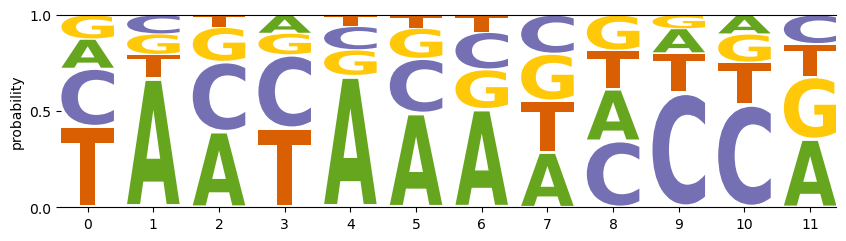

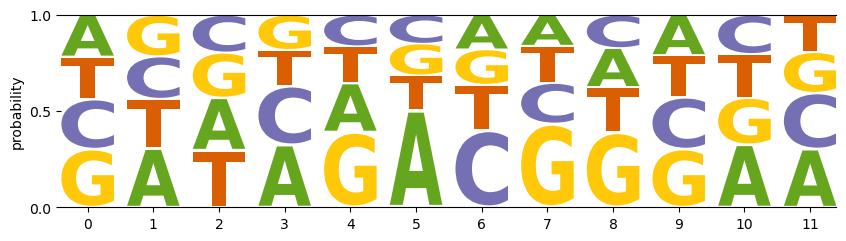

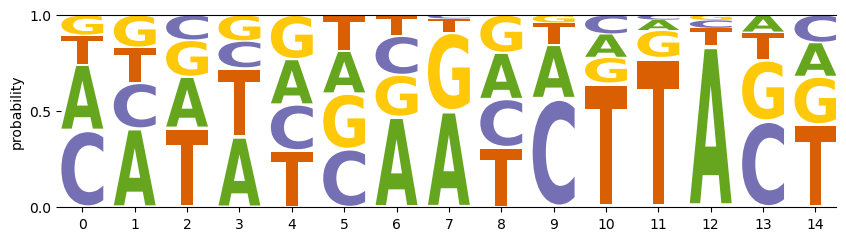

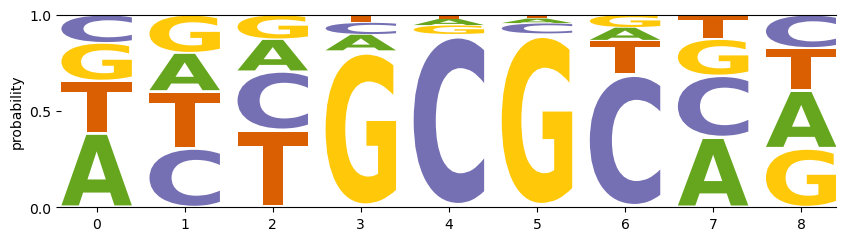

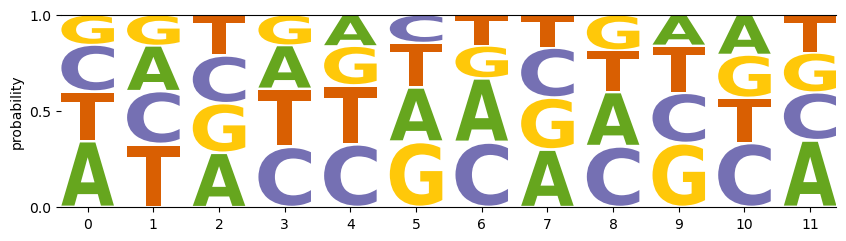

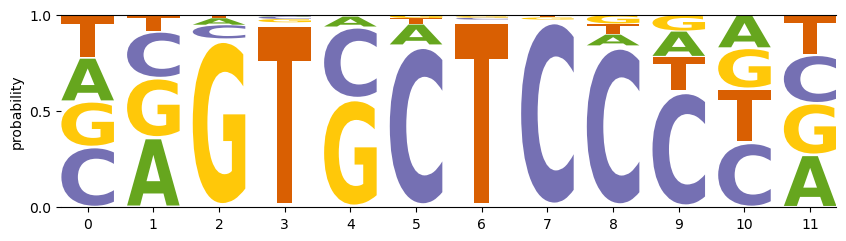

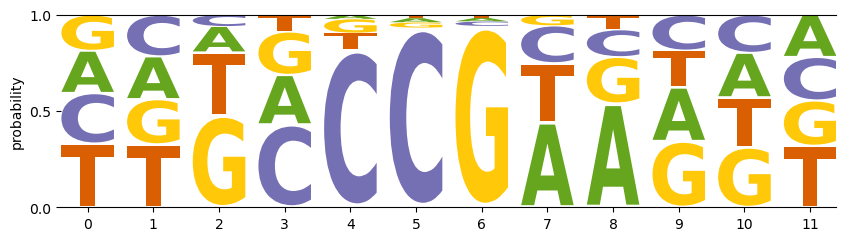

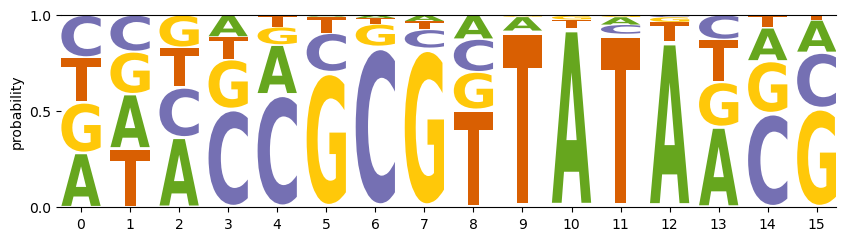

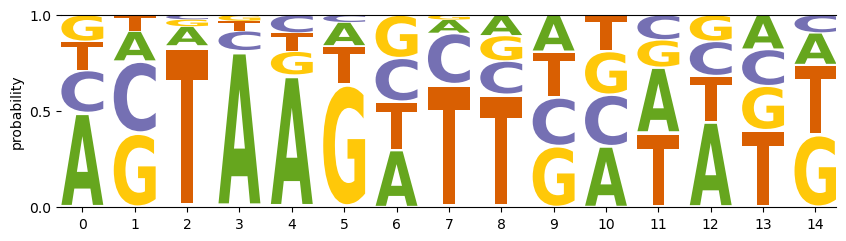

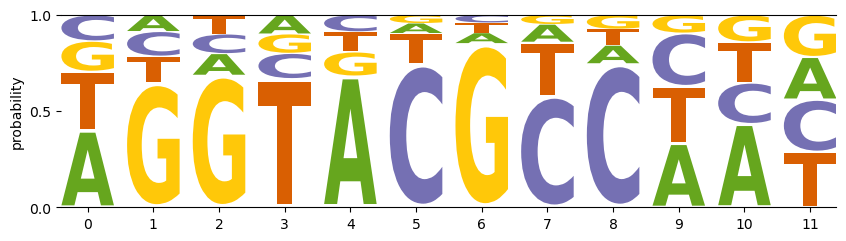

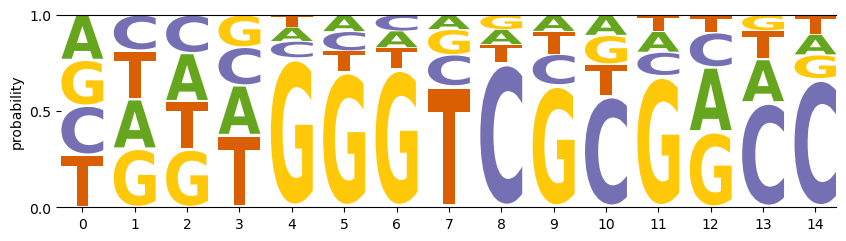

In [4]:
#all logos
for file in files:
    name = file.split('/')[-1][:-4]
    dGG = pd.read_csv(file, index_col=0)

    # First get mu's
    mean_values = dGG.max(axis=1)



    dGG_m = dGG.add(-mean_values, axis='rows')



    # ProBound uses ln
    psam = np.e**(dGG_m)



    # Now let's simulate the frequencies, creating the postion frequency matrix
    pfm = psam
    pfm = pfm.T

    probs = functions.pfm_to_ppm(pfm)

    probs.to_csv(os.path.join(results_path, f'{name}_ppm.csv'))

    fig, ax = plt.subplots(1,1,figsize=[10,2.5])

    logo = logomaker.Logo(probs.T,
                        ax=ax,
                        width=.8,
                        vpad=.05,
                        fade_probabilities=False,
                        stack_order='small_on_top',
                        color_scheme={'A':'#66a61e', 'C':'#7570b3','G':'#ffc809','T':'#d95f02','m':'#a6cee3'}
                        )
    # style using Logo methods
    logo.style_spines(spines=['left', 'right'], visible=False)


    # style using Axes methods
    logo.ax.set_ylabel('probability')
    logo.ax.set_yticks([0, .5, 1])
    logo.ax.set_xticks(range(len(probs.T)))


    fig.savefig(os.path.join(results_path, 'ppm_logo', f'{name}_ppm.pdf'), format='pdf')
    fig.savefig(os.path.join(results_path, 'ppm_logo', f'{name}_ppm.png'), format='png', dpi= 600)
    plt.show()

Single example

In [27]:
dGG = pd.read_csv(file[1], index_col=0)

In [13]:
dGG

,A,C,G,T
0,0.154614,-0.273980,-0.680121,-0.441414
1,1.075202,-1.108640,-0.671285,-0.536179
2,-0.649214,-0.706342,-1.555110,1.669765
3,-0.105819,-0.822443,-1.128284,0.815645
4,0.420965,-0.902677,-2.039077,1.279888
5,0.022016,-1.122299,1.013195,-1.153813
6,0.427692,2.116134,-1.700913,-2.083814
7,1.967667,-0.794896,-0.793186,-1.620486
8,-0.552775,-1.269638,-1.650734,2.232245
9,1.137904,-1.387362,-0.963506,-0.027937


In [29]:
# First get mu's
mean_values = dGG.max(axis=1)



dGG_m = dGG.add(-mean_values, axis='rows')



# ProBound uses ln
psam = np.e**(dGG_m)



# Now let's simulate the frequencies, creating the postion frequency matrix
pfm = psam
pfm = pfm.T

probs = functions.pfm_to_ppm(pfm)

In [5]:
probs.T

,A,C,G,T
0,0.234247,0.254632,0.237854,0.273267
1,0.256616,0.184639,0.304802,0.253944
2,0.249964,0.198671,0.301105,0.250260
3,0.258340,0.198570,0.167832,0.375258
4,0.073042,0.084920,0.777149,0.064888
5,0.087097,0.100397,0.707876,0.104630
6,0.086529,0.084076,0.720795,0.108600
7,0.076265,0.162641,0.131081,0.630012
8,0.077999,0.750922,0.076052,0.095026
9,0.085885,0.159711,0.635812,0.118591


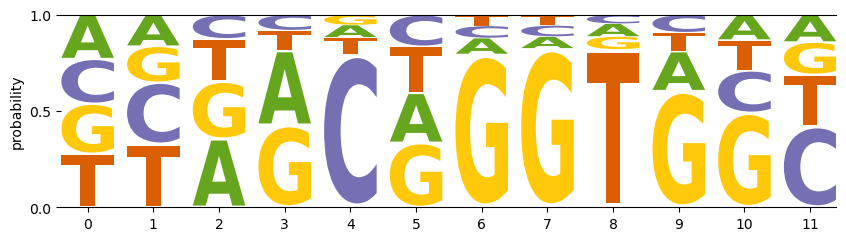

In [30]:
fig, ax = plt.subplots(1,1,figsize=[10,2.5])
logo = logomaker.Logo(probs.T,
                    ax=ax,
                    width=.8,
                    vpad=.05,
                    fade_probabilities=False,
                    stack_order='small_on_top',
                    color_scheme={'A':'#66a61e', 'C':'#7570b3','G':'#ffc809','T':'#d95f02','m':'#a6cee3'}
                    )
# style using Logo methods
logo.style_spines(spines=['left', 'right'], visible=False)


# style using Axes methods
logo.ax.set_ylabel('probability')
logo.ax.set_yticks([0, .5, 1])
logo.ax.set_xticks(range(len(probs.T)))


#fig.savefig(results_path + "ppm_logo.pdf", format='pdf')
#fig.savefig(results_path + "ppm_logo.png", format='png', dpi= 600)
plt.show()